In [1]:
!pip install scikit-image

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

2026-02-02 12:22:21.058926: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-02 12:22:21.091415: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-02 12:22:21.861169: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# map inputs to (-1, +1) for better training
x_train, x_test = x_train / 255.0 * 2 - 1, x_test / 255.0 * 2 - 1
print("x_train.shape:", x_train.shape)

x_train.shape: (60000, 28, 28)


In [4]:
# Flatten the data
N, H, W = x_train.shape
D = H * W
x_train = x_train.reshape(-1, D)
x_test = x_test.reshape(-1, D)

In [5]:
# Dimensionality of the latent space
latent_dim = 100

In [6]:
# Get the generator model
def build_generator(latent_dim):
  i = Input(shape=(latent_dim,))
  x = Dense(256, activation=LeakyReLU(negative_slope=0.2))(i)
  x = BatchNormalization(momentum=0.7)(x)
  x = Dense(512, activation=LeakyReLU(negative_slope=0.2))(x)
  x = BatchNormalization(momentum=0.7)(x)
  x = Dense(1024, activation=LeakyReLU(negative_slope=0.2))(x)
  x = BatchNormalization(momentum=0.7)(x)
  x = Dense(D, activation='tanh')(x)

  model = Model(i, x)
  return model

In [7]:
# Get the discriminator model
def build_discriminator(img_size):
  i = Input(shape=(img_size,))
  x = Dense(512, activation=LeakyReLU(negative_slope=0.2))(i)
  x = Dense(256, activation=LeakyReLU(negative_slope=0.2))(x)
  x = Dense(1, activation='sigmoid')(x)
  model = Model(i, x)
  return model

In [8]:
# Compile both models in preparation for training


# Build and compile the discriminator
discriminator = build_discriminator(D)
discriminator.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002, 0.5),
    metrics=['accuracy'])

# Build and compile the combined model
generator = build_generator(latent_dim)

# Create an input to represent noise sample from latent space
z = Input(shape=(latent_dim,))

# Pass noise through generator to get an image
img = generator(z)

# Make sure only the generator is trained
# In older versions of TF2, it worked to only set this once
# which did not make a lot of sense!
# The way it works now is better.
# When we want to train discriminator, we unfreeze
# When we want to train generator, we freeze
discriminator.trainable = False

# The true output is fake, but we label them real!
fake_pred = discriminator(img)

# Create the combined model object
combined_model = Model(z, fake_pred)

# Compile the combined model
combined_model.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))

I0000 00:00:1770016943.187210  464108 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4019 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


In [9]:
# Train the GAN


# Config
batch_size = 32
epochs = 30000
sample_period = 200  # every `sample_period` steps generate and save some data


# Create batch labels to use when calling train_on_batch
ones = np.ones(batch_size)
zeros = np.zeros(batch_size)

# Store the losses
d_losses = []
g_losses = []

# Create a folder to store generated images
if not os.path.exists('gan_images'):
  os.makedirs('gan_images')

In [10]:
# A function to generate a grid of random samples from the generator
# and save them to a file
def sample_images(epoch):
  rows, cols = 5, 5
  noise = np.random.randn(rows * cols, latent_dim)
  imgs = generator.predict(noise, verbose=0)

  # Rescale images 0 - 1
  imgs = 0.5 * imgs + 0.5

  fig, axs = plt.subplots(rows, cols)
  idx = 0
  for i in range(rows):
    for j in range(cols):
      axs[i, j].imshow(imgs[idx].reshape(H, W), cmap='gray')
      axs[i, j].axis('off')
      idx += 1
  fig.savefig("gan_images/%d.png" % epoch)
  plt.close()

In [11]:
# Main training loop
for epoch in range(epochs):
    ###########################
    ### Train discriminator ###
    ###########################

    discriminator.trainable = True

    # Select a random batch of images
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]

    # Generate fake images
    noise = np.random.randn(batch_size, latent_dim)
    fake_imgs = generator(noise)

    # Train the discriminator
    # both loss and accuracy are returned
    d_loss_real, d_acc_real = discriminator.train_on_batch(real_imgs, ones)
    d_loss_fake, d_acc_fake = discriminator.train_on_batch(fake_imgs, zeros)
    d_loss = 0.5 * (d_loss_real + d_loss_fake)
    d_acc = 0.5 * (d_acc_real + d_acc_fake)

    #######################
    ### Train generator ###
    #######################

    discriminator.trainable = False

    noise = np.random.randn(batch_size, latent_dim)
    g_loss1 = combined_model.train_on_batch(noise, ones)
    # print("g_loss 1:", g_loss)

    # do it again!
    noise = np.random.randn(batch_size, latent_dim)
    g_loss2 = combined_model.train_on_batch(noise, ones)
    # print("g_loss 2:", g_loss)
    noise = np.random.randn(batch_size, latent_dim)
    g_loss3 = combined_model.train_on_batch(noise, ones)

    g_loss = (g_loss1 + g_loss2+g_loss3)/3

    # Save the losses
    d_losses.append(d_loss)
    g_losses.append(g_loss)

    if epoch % 100 == 0:
        print(
            f"epoch: {epoch+1}/{epochs}, d_loss: {d_loss:.2f}, d_acc: {d_acc:.2f}, g_loss: {g_loss:.2f}")

    if epoch % sample_period == 0:
        sample_images(epoch)

2026-02-02 12:22:24.000199: I external/local_xla/xla/service/service.cc:163] XLA service 0x4920b220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-02 12:22:24.000213: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 SUPER, Compute Capability 7.5
2026-02-02 12:22:24.010749: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-02 12:22:24.086704: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
I0000 00:00:1770016944.480734  464108 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


epoch: 1/30000, d_loss: 0.87, d_acc: 0.26, g_loss: 0.69
epoch: 101/30000, d_loss: 0.19, d_acc: 0.93, g_loss: 2.14
epoch: 201/30000, d_loss: 0.44, d_acc: 0.73, g_loss: 1.57
epoch: 301/30000, d_loss: 0.54, d_acc: 0.64, g_loss: 1.25
epoch: 401/30000, d_loss: 0.59, d_acc: 0.60, g_loss: 1.09
epoch: 501/30000, d_loss: 0.61, d_acc: 0.57, g_loss: 1.00
epoch: 601/30000, d_loss: 0.63, d_acc: 0.55, g_loss: 0.95
epoch: 701/30000, d_loss: 0.64, d_acc: 0.54, g_loss: 0.91
epoch: 801/30000, d_loss: 0.65, d_acc: 0.53, g_loss: 0.88
epoch: 901/30000, d_loss: 0.65, d_acc: 0.52, g_loss: 0.86
epoch: 1001/30000, d_loss: 0.66, d_acc: 0.51, g_loss: 0.85
epoch: 1101/30000, d_loss: 0.66, d_acc: 0.51, g_loss: 0.83
epoch: 1201/30000, d_loss: 0.67, d_acc: 0.50, g_loss: 0.82
epoch: 1301/30000, d_loss: 0.67, d_acc: 0.50, g_loss: 0.82
epoch: 1401/30000, d_loss: 0.67, d_acc: 0.50, g_loss: 0.81
epoch: 1501/30000, d_loss: 0.67, d_acc: 0.50, g_loss: 0.80
epoch: 1601/30000, d_loss: 0.67, d_acc: 0.50, g_loss: 0.80
epoch: 17

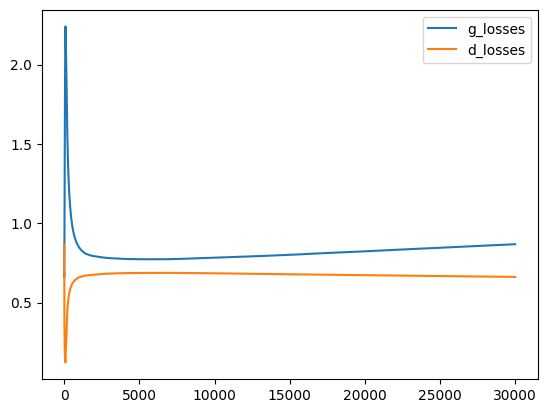

In [12]:
plt.plot(g_losses, label='g_losses')
plt.plot(d_losses, label='d_losses')
plt.legend()

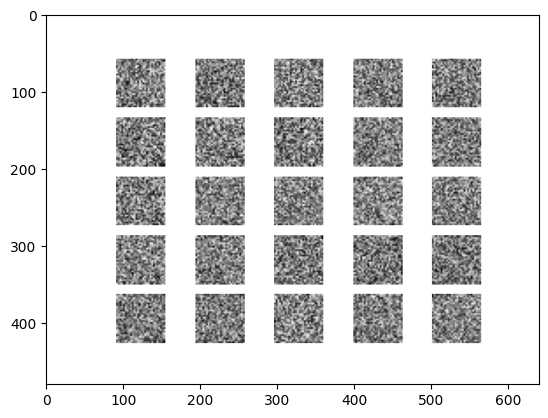

In [13]:
from skimage.io import imread
a = imread('gan_images/0.png')
plt.imshow(a)

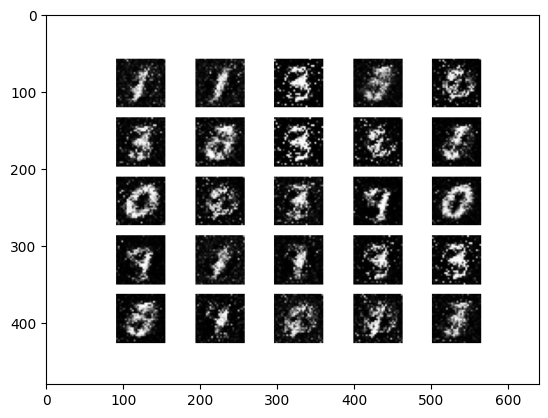

In [14]:
a = imread('gan_images/1000.png')
plt.imshow(a)

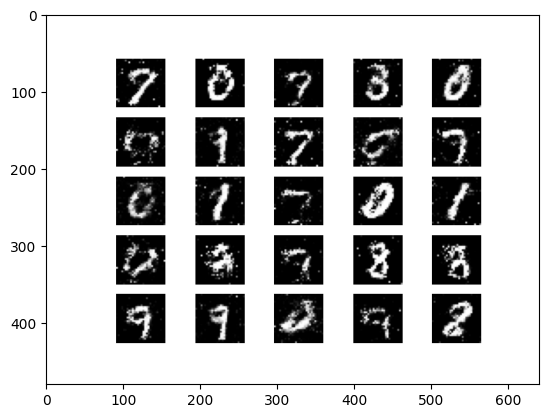

In [15]:
a = imread('gan_images/5000.png')
plt.imshow(a)

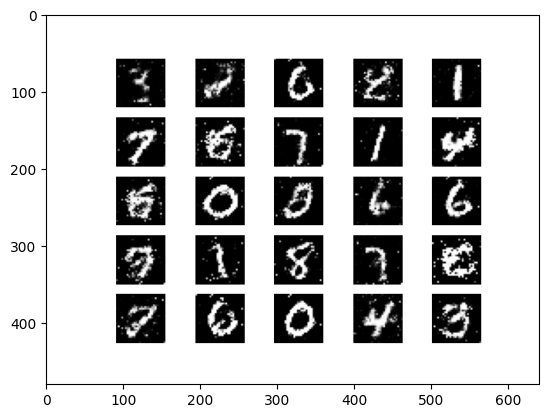

In [16]:
a = imread('gan_images/10000.png')
plt.imshow(a)

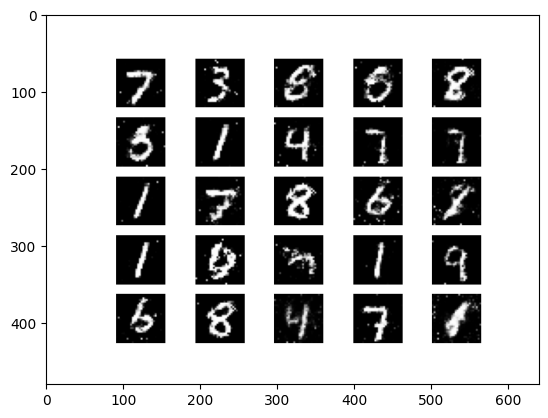

In [17]:
a = imread('gan_images/20000.png')
plt.imshow(a)

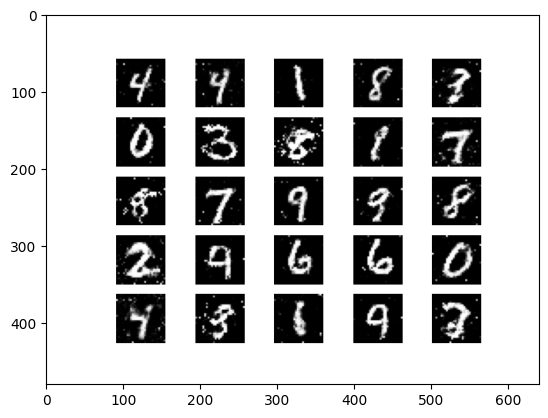

In [18]:
a = imread('gan_images/29800.png')
plt.imshow(a)